# Hindi Text Preprocessing and Corpus Statistics Analysis

This notebook implements complete Hindi text preprocessing including:
1. Tokenization
2. Unicode Normalization
3. Zero-Width Character Handling
4. Diacritic Normalization
5. Stopword Removal
6. Rule-Based Stemming
7. Corpus Statistics (Zipf's and Heaps' Laws)

All preprocessing stages include detailed examples and visualizations.

In [ ]:
# Import required libraries
import sys
import os
import unicodedata
import re
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Set, Dict, Tuple
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import importlib

# Add src directory to path for imports
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

# Import preprocessing module and reload to ensure latest changes
import preprocessing
importlib.reload(preprocessing)
from preprocessing import HindiPreprocessor, calculate_vocabulary_impact

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load and Prepare Hindi Corpus

Load Hindi text files from the data directory and prepare for preprocessing.

In [45]:
# Load Hindi corpus files
def load_hindi_corpus(data_dir: str = 'data/hindi', sample_size: int = None) -> List[str]:
    """
    Load Hindi text files from directory
    
    Args:
        data_dir: Directory containing Hindi text files
        sample_size: Number of files to load (None = all)
    
    Returns:
        List of text documents
    """
    texts = []
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"Warning: Directory {data_dir} not found")
        return texts
    
    # Load all .txt files
    files = sorted(data_path.glob('*.txt'))
    
    if sample_size:
        files = files[:sample_size]
    
    print(f"Loading {len(files)} Hindi text files...")
    
    for file_path in files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read()
                if text.strip():  # Only add non-empty texts
                    texts.append(text)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    return texts

# Load corpus (sample first 30 files for computational efficiency)
hindi_texts = load_hindi_corpus(sample_size=30)
print(f"Loaded {len(hindi_texts)} documents")

# Combine all texts into one corpus for analysis
combined_corpus = "\n".join(hindi_texts)
print(f"Combined corpus size: {len(combined_corpus)} characters")
print(f"Sample text (first 200 chars): {combined_corpus[:200]}...")

Loading 30 Hindi text files...
Loaded 30 documents
Combined corpus size: 342986 characters
Sample text (first 200 chars): # हम होंगे कामयाब

हम होंगे कामयाब ( का गिरिजा कुमार माथुर द्वारा किया गया हिंदी भावानुवाद) एक प्रतिरोध गीत है। यह गीत बीसवीं सदी में नागरिक अधिकार आंदोलन का प्रधान स्वर बना। इस गीत को आमतौर पर "I'll ...


## Section 2: Tokenization for Hindi Text

Implement word tokenization handling Hindi-specific punctuation, diacritics, and numerals.

In [46]:
# Test tokenization on sample texts
print("=" * 60)
print("TOKENIZATION EXAMPLES")
print("=" * 60)

preprocessor = HindiPreprocessor()

# Test on various Hindi texts
test_samples = [
    "नमस्ते! आप कैसे हैं?",
    "भारत एक महान देश है।",
    "मुझे किताब दी। (क्या यह सच है?)",
    "राष्ट्र का निर्माण करना आवश्यक है।",
    "अंग्रेजी सीखना महत्वपूर्ण है।"
]

for i, text in enumerate(test_samples, 1):
    tokens = preprocessor.tokenize(text)
    print(f"\nSample {i}:")
    print(f"Text: {text}")
    print(f"Tokens ({len(tokens)}): {tokens}")

# Tokenize full corpus
print("\n" + "=" * 60)
print("FULL CORPUS TOKENIZATION")
print("=" * 60)
corpus_tokens = preprocessor.tokenize(combined_corpus)
print(f"Total tokens in corpus: {len(corpus_tokens)}")
print(f"Unique tokens: {len(set(corpus_tokens))}")
print(f"Sample tokens: {corpus_tokens[:20]}")

TOKENIZATION EXAMPLES

Sample 1:
Text: नमस्ते! आप कैसे हैं?
Tokens (4): ['नमस्ते', 'आप', 'कैसे', 'हैं']

Sample 2:
Text: भारत एक महान देश है।
Tokens (5): ['भारत', 'एक', 'महान', 'देश', 'है']

Sample 3:
Text: मुझे किताब दी। (क्या यह सच है?)
Tokens (7): ['मुझे', 'किताब', 'दी', 'क्या', 'यह', 'सच', 'है']

Sample 4:
Text: राष्ट्र का निर्माण करना आवश्यक है।
Tokens (6): ['राष्ट्र', 'का', 'निर्माण', 'करना', 'आवश्यक', 'है']

Sample 5:
Text: अंग्रेजी सीखना महत्वपूर्ण है।
Tokens (4): ['अंग्रेजी', 'सीखना', 'महत्वपूर्ण', 'है']

FULL CORPUS TOKENIZATION
Total tokens in corpus: 61755
Unique tokens: 10461
Sample tokens: ['#', 'हम', 'होंगे', 'कामयाब', 'हम', 'होंगे', 'कामयाब', 'का', 'गिरिजा', 'कुमार', 'माथुर', 'द्वारा', 'किया', 'गया', 'हिंदी', 'भावानुवाद', 'एक', 'प्रतिरोध', 'गीत', 'है']


## Section 3: Unicode Normalization (NFC)

Apply NFC normalization to ensure canonically equivalent strings match.

In [47]:
print("=" * 60)
print("UNICODE NFC NORMALIZATION EXAMPLES")
print("=" * 60)

# Example 1: Show NFC normalization
test_text = "आप कैसे हैं"
normalized = preprocessor.normalize_unicode(test_text)

print(f"\nExample 1: Basic Text")
print(f"Original: {test_text}")
print(f"Normalized: {normalized}")
print(f"Byte representation:")
print(f"  Original bytes: {test_text.encode('utf-8')}")
print(f"  Normalized bytes: {normalized.encode('utf-8')}")

# Example 2: Demonstrate canonical equivalence
print(f"\nExample 2: Canonical Equivalence")
# Some characters can be represented as precomposed or decomposed
text_with_decomposed = "क\u093e"  # क + ा (decomposed)
text_with_precomposed = "का"  # precomposed
print(f"Decomposed (क + ा): {text_with_decomposed}")
print(f"Precomposed (का): {text_with_precomposed}")
print(f"After NFC, both become: {unicodedata.normalize('NFC', text_with_decomposed)}")

# Verify they match after normalization
nfc_decomposed = unicodedata.normalize('NFC', text_with_decomposed)
nfc_precomposed = unicodedata.normalize('NFC', text_with_precomposed)
print(f"Are they equal after NFC? {nfc_decomposed == nfc_precomposed}")

# Apply to full corpus
normalized_corpus = preprocessor.preprocess_text(combined_corpus)
print(f"\nFull corpus normalization:")
print(f"Original length: {len(combined_corpus)} characters")
print(f"Normalized length: {len(normalized_corpus)} characters")

UNICODE NFC NORMALIZATION EXAMPLES

Example 1: Basic Text
Original: आप कैसे हैं
Normalized: आप कैसे हैं
Byte representation:
  Original bytes: b'\xe0\xa4\x86\xe0\xa4\xaa \xe0\xa4\x95\xe0\xa5\x88\xe0\xa4\xb8\xe0\xa5\x87 \xe0\xa4\xb9\xe0\xa5\x88\xe0\xa4\x82'
  Normalized bytes: b'\xe0\xa4\x86\xe0\xa4\xaa \xe0\xa4\x95\xe0\xa5\x88\xe0\xa4\xb8\xe0\xa5\x87 \xe0\xa4\xb9\xe0\xa5\x88\xe0\xa4\x82'

Example 2: Canonical Equivalence
Decomposed (क + ा): का
Precomposed (का): का
After NFC, both become: का
Are they equal after NFC? True

Full corpus normalization:
Original length: 342986 characters
Normalized length: 342602 characters


## Section 4: Zero-Width Character Handling

Remove ZWJ (U+200D) and ZWNJ (U+200C) characters after NFC normalization.

In [48]:
print("=" * 60)
print("ZERO-WIDTH CHARACTER HANDLING")
print("=" * 60)

# Example 1: ZWJ (Zero-Width Joiner) removal
print("\nExample 1: ZWJ Removal (U+200D)")
text_with_zwj = "र\u200Dष्ट्र"  # With ZWJ for ligature
text_without_zwj = preprocessor.remove_zwj_zwnj(text_with_zwj)
print(f"With ZWJ: '{text_with_zwj}' (len={len(text_with_zwj)})")
print(f"Without ZWJ: '{text_without_zwj}' (len={len(text_without_zwj)})")
print(f"Characters removed: {len(text_with_zwj) - len(text_without_zwj)}")

# Example 2: ZWNJ (Zero-Width Non-Joiner) removal
print("\nExample 2: ZWNJ Removal (U+200C)")
text_with_zwnj = "क\u200Cष"  # With ZWNJ to prevent ligature
text_without_zwnj = preprocessor.remove_zwj_zwnj(text_with_zwnj)
print(f"With ZWNJ: '{text_with_zwnj}' (len={len(text_with_zwnj)})")
print(f"Without ZWNJ: '{text_without_zwnj}' (len={len(text_without_zwnj)})")

# Example 3: Check corpus for ZWJ/ZWNJ
print("\nExample 3: Check corpus for ZWJ/ZWNJ")
zwj_count = combined_corpus.count('\u200D')
zwnj_count = combined_corpus.count('\u200C')
print(f"ZWJ occurrences in corpus: {zwj_count}")
print(f"ZWNJ occurrences in corpus: {zwnj_count}")

if zwj_count > 0 or zwnj_count > 0:
    print("Zero-width characters found and will be removed during preprocessing")
else:
    print("No zero-width characters found in corpus")

ZERO-WIDTH CHARACTER HANDLING

Example 1: ZWJ Removal (U+200D)
With ZWJ: 'र‍ष्ट्र' (len=7)
Without ZWJ: 'रष्ट्र' (len=6)
Characters removed: 1

Example 2: ZWNJ Removal (U+200C)
With ZWNJ: 'क‌ष' (len=3)
Without ZWNJ: 'कष' (len=2)

Example 3: Check corpus for ZWJ/ZWNJ
ZWJ occurrences in corpus: 131
ZWNJ occurrences in corpus: 21
Zero-width characters found and will be removed during preprocessing


## Section 5: Diacritic and Vowel Sign Normalization

Normalize script-specific diacritics (matras) and vowel sign variants.

In [49]:
print("=" * 60)
print("DIACRITIC AND VOWEL SIGN NORMALIZATION")
print("=" * 60)

# Example 1: Nasalization normalization (Chandrabindu to Anusvara)
print("\nExample 1: Nasalization Mark Normalization")
print("Chandrabindu (ँ U+0981) vs Anusvara (ं U+0902)")
text_chandrabindu = "हँ"  # With chandrabindu (archaic)
text_anusvara = "हं"      # With anusvara (modern)
normalized_chandrabindu = preprocessor.normalize_nasalization(text_chandrabindu)

print(f"Chandrabindu form: '{text_chandrabindu}'")
print(f"Anusvara form: '{text_anusvara}'")
print(f"After normalization: '{normalized_chandrabindu}'")
print(f"Both now match? {normalized_chandrabindu == text_anusvara}")

# Example 2: Vowel sign variants
print("\nExample 2: Vowel Sign Normalization")
print("Hindi vowel signs (matras):")
vowel_examples = {
    "का": "क + ा (a-kar)",
    "की": "क + ी (ii-kar)",
    "कु": "क + ु (u-kar)",
    "कूँ": "क + ू (uu-kar) with nasalization",
    "के": "क + े (e-kar)",
    "कै": "क + ै (ai-kar)",
    "को": "क + ो (o-kar)",
    "कौ": "क + ौ (au-kar)",
}

for text, description in vowel_examples.items():
    normalized = preprocessor.normalize_diacritics(text)
    print(f"  {text} ({description})")

# Example 3: Show the full normalization pipeline
print("\nExample 3: Full Normalization Pipeline")
raw_text = "चंद्रबिंदु परीक्षा"
print(f"Raw text: {raw_text}")

# Step by step normalization
step1 = preprocessor.normalize_unicode(raw_text)
print(f"After NFC: {step1}")

step2 = preprocessor.remove_zwj_zwnj(step1)
print(f"After ZWJ/ZWNJ removal: {step2}")

step3 = preprocessor.normalize_diacritics(step2)
print(f"After diacritic normalization: {step3}")

step4 = preprocessor.normalize_nasalization(step3)
print(f"After nasalization normalization: {step4}")

final = preprocessor.preprocess_text(raw_text)
print(f"Full pipeline result: {final}")
print(f"Characters before: {len(raw_text)}, after: {len(final)}")

DIACRITIC AND VOWEL SIGN NORMALIZATION

Example 1: Nasalization Mark Normalization
Chandrabindu (ँ U+0981) vs Anusvara (ं U+0902)
Chandrabindu form: 'हँ'
Anusvara form: 'हं'
After normalization: 'हं'
Both now match? True

Example 2: Vowel Sign Normalization
Hindi vowel signs (matras):
  का (क + ा (a-kar))
  की (क + ी (ii-kar))
  कु (क + ु (u-kar))
  कूँ (क + ू (uu-kar) with nasalization)
  के (क + े (e-kar))
  कै (क + ै (ai-kar))
  को (क + ो (o-kar))
  कौ (क + ौ (au-kar))

Example 3: Full Normalization Pipeline
Raw text: चंद्रबिंदु परीक्षा
After NFC: चंद्रबिंदु परीक्षा
After ZWJ/ZWNJ removal: चंद्रबिंदु परीक्षा
After diacritic normalization: चंद्रबिंदु परीक्षा
After nasalization normalization: चंद्रबिंदु परीक्षा
Full pipeline result: चंद्रबिंदु परीक्षा
Characters before: 18, after: 18


## Section 6: Stopword Removal

Create a minimum 30-word Hindi stopword list and analyze impact on vocabulary size.

In [ ]:
print("=" * 60)
print("STOPWORD REMOVAL ANALYSIS")
print("=" * 60)

# Load preprocessor with stopwords
stopwords_path = 'data/stopwords_hindi.txt'
preprocessor_with_stopwords = HindiPreprocessor(stopwords_path=stopwords_path)

stopword_count = preprocessor_with_stopwords.get_stopword_count()
print(f"\nLoaded {stopword_count} stopwords")

if stopword_count > 0:
    # Get some stopword examples
    stopwords_list = list(preprocessor_with_stopwords.stopwords)[:15]
    print(f"Sample stopwords: {stopwords_list}")

# Test on sample text
test_text = "यह किताब है और यह बहुत अच्छी है। मैं इसे पढ़ना चाहता हूँ।"
print(f"\nTest text: {test_text}")

# Tokenize without stopword removal
tokens_before = preprocessor_with_stopwords.process(test_text, 
                                                    remove_stopwords=False)
print(f"\nTokens before stopword removal ({len(tokens_before)}): {tokens_before}")

# Tokenize with stopword removal
tokens_after = preprocessor_with_stopwords.process(test_text, 
                                                   remove_stopwords=True)
print(f"Tokens after stopword removal ({len(tokens_after)}): {tokens_after}")

# Analysis on full corpus
print("\n" + "-" * 60)
print("VOCABULARY IMPACT ANALYSIS ON FULL CORPUS")
print("-" * 60)

# Get raw tokens
raw_tokens = preprocessor_with_stopwords.process(combined_corpus, 
                                                remove_stopwords=False)
# Get filtered tokens
filtered_tokens = preprocessor_with_stopwords.process(combined_corpus, 
                                                     remove_stopwords=True)

# Calculate impact using the imported function
impact = calculate_vocabulary_impact(raw_tokens, filtered_tokens)

print(f"\nOriginal vocabulary size: {impact['original_vocab_size']} unique words")
print(f"Filtered vocabulary size: {impact['filtered_vocab_size']} unique words")
print(f"Vocabulary reduction: {impact['vocab_reduction_pct']:.2f}%")
print(f"\nTotal tokens originally: {impact['total_tokens_original']}")
print(f"Total tokens after filtering: {impact['total_tokens_filtered']}")
print(f"Tokens removed: {impact['tokens_removed']} ({(impact['tokens_removed']/impact['total_tokens_original']*100):.2f}%)")
print(f"Unique stopwords removed: {impact['removed_word_count']}")

STOPWORD REMOVAL ANALYSIS

Loaded 0 stopwords

Test text: यह किताब है और यह बहुत अच्छी है। मैं इसे पढ़ना चाहता हूँ।

Tokens before stopword removal (13): ['यह', 'किताब', 'है', 'और', 'यह', 'बहुत', 'अच्छी', 'है', 'मैं', 'इसे', 'पढ़ना', 'चाहता', 'हूं']
Tokens after stopword removal (13): ['यह', 'किताब', 'है', 'और', 'यह', 'बहुत', 'अच्छी', 'है', 'मैं', 'इसे', 'पढ़ना', 'चाहता', 'हूं']

------------------------------------------------------------
VOCABULARY IMPACT ANALYSIS ON FULL CORPUS
------------------------------------------------------------

Original vocabulary size: 10323 unique words
Filtered vocabulary size: 10323 unique words
Vocabulary reduction: 0.00%

Total tokens originally: 61755
Total tokens after filtering: 61755
Tokens removed: 0 (0.00%)
Unique stopwords removed: 0


## Section 7: Rule-Based Hindi Stemming

Implement a rule-based stemmer for Hindi suffix removal and test on sample words.

In [51]:
print("=" * 60)
print("HINDI STEMMING ANALYSIS")
print("=" * 60)

# Test set of 50+ Hindi words for stemming
test_words = [
    ('किताबों', 'किताब', 'books -> book (plural)'),
    ('किताब', 'किताब', 'book (unchanged)'),
    ('बोलना', 'बोल', 'to speak (infinitive)'),
    ('बोलता', 'बोल', 'speaks (habitual)'),
    ('बोलती', 'बोल', 'speaks (feminine)'),
    ('बोलते', 'बोल', 'speak (plural)'),
    ('सुंदरी', 'सुंदर', 'beautiful (feminine)'),
    ('सुंदर', 'सुंदर', 'beautiful (masculine)'),
    ('दिलों', 'दिल', 'hearts -> heart (plural)'),
    ('दिल', 'दिल', 'heart (unchanged)'),
    ('जाना', 'जा', 'to go (infinitive)'),
    ('जाता', 'जा', 'goes (habitual)'),
    ('जागा', 'जा', 'went (past)'),
    ('भारत', 'भारत', 'India (proper noun)'),
    ('भारतीय', 'भारत', 'Indian'),
    ('भारतीयों', 'भारत', 'Indians (plural)'),
    ('खेलना', 'खेल', 'to play (infinitive)'),
    ('खेलता', 'खेल', 'plays (habitual)'),
    ('खेल', 'खेल', 'play (noun)'),
    ('पढ़ना', 'पढ', 'to read (infinitive)'),
    ('पढ़ता', 'पढ', 'reads (habitual)'),
    ('पढ़ी', 'पढ', 'read (feminine past)'),
    ('लिखना', 'लिख', 'to write (infinitive)'),
    ('लिखता', 'लिख', 'writes (habitual)'),
    ('लिखा', 'लिख', 'written (masculine)'),
    ('नाचना', 'नाच', 'to dance (infinitive)'),
    ('नाचती', 'नाच', 'dances (feminine)'),
    ('गीत', 'गीत', 'song (unchanged)'),
    ('गीतों', 'गीत', 'songs (plural)'),
    ('रंग', 'रंग', 'color (unchanged)'),
    ('रंगों', 'रंग', 'colors (plural)'),
    ('मनुष्य', 'मनुष्य', 'man/human (unchanged)'),
    ('मनुष्यों', 'मनुष्य', 'men/humans (plural)'),
    ('आनंद', 'आनंद', 'joy (unchanged)'),
    ('आनंदी', 'आनंद', 'joyful (adjective)'),
    ('शक्ति', 'शक्ति', 'power/strength'),
    ('शक्तिशाली', 'शक्ति', 'powerful'),
    ('दक्षिण', 'दक्षिण', 'south (unchanged)'),
    ('पश्चिम', 'पश्चिम', 'west (unchanged)'),
    ('उत्तर', 'उत्तर', 'north/answer'),
    ('पूर्व', 'पूर्व', 'east/previous'),
    ('शिक्षक', 'शिक्षक', 'teacher (unchanged)'),
    ('शिक्षकों', 'शिक्षक', 'teachers (plural)'),
    ('डॉक्टर', 'डॉक्टर', 'doctor (unchanged)'),
    ('मजदूर', 'मजदूर', 'laborer (unchanged)'),
    ('मजदूरों', 'मजदूर', 'laborers (plural)'),
    ('देश', 'देश', 'country (unchanged)'),
    ('देशों', 'देश', 'countries (plural)'),
    ('सरकार', 'सरकार', 'government (unchanged)'),
    ('सरकारी', 'सरकार', 'governmental/official'),
    ('राजा', 'राजा', 'king (unchanged)'),
    ('राजाओं', 'राजा', 'kings (plural)'),
    ('रानी', 'रान', 'queen (feminine)'),
]

# Perform stemming and measure accuracy
correct = 0
incorrect = 0
stem_results = []

print(f"\nStemming {len(test_words)} words:\n")
print(f"{'Word':<15} {'Expected':<15} {'Got':<15} {'Status':<10} {'Note':<30}")
print("-" * 85)

for word, expected, description in test_words:
    stemmed = preprocessor.stem_word(word)
    is_correct = stemmed == expected
    status = "✓ CORRECT" if is_correct else "✗ WRONG"
    
    if is_correct:
        correct += 1
    else:
        incorrect += 1
    
    print(f"{word:<15} {expected:<15} {stemmed:<15} {status:<10} {description:<30}")
    stem_results.append({
        'word': word,
        'expected': expected,
        'got': stemmed,
        'correct': is_correct
    })

print("-" * 85)
accuracy = (correct / len(test_words)) * 100
print(f"\nStemming Results:")
print(f"Total words tested: {len(test_words)}")
print(f"Correct: {correct}")
print(f"Incorrect: {incorrect}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Error rate: {100-accuracy:.2f}%")

HINDI STEMMING ANALYSIS

Stemming 53 words:

Word            Expected        Got             Status     Note                          
-------------------------------------------------------------------------------------
किताबों         किताब           किताब           ✓ CORRECT  books -> book (plural)        
किताब           किताब           किताब           ✓ CORRECT  book (unchanged)              
बोलना           बोल             बोल             ✓ CORRECT  to speak (infinitive)         
बोलता           बोल             बोल             ✓ CORRECT  speaks (habitual)             
बोलती           बोल             बोल             ✓ CORRECT  speaks (feminine)             
बोलते           बोल             बोल             ✓ CORRECT  speak (plural)                
सुंदरी          सुंदर           सुंदर           ✓ CORRECT  beautiful (feminine)          
सुंदर           सुंदर           सुंदर           ✓ CORRECT  beautiful (masculine)         
दिलों           दिल             दिल             ✓ CORRECT  

## Section 8: Corpus Statistics - Zipf's Law

Compute Zipf's law by ranking words by frequency and analyzing the power-law distribution.

In [52]:
print("=" * 60)
print("ZIPF'S LAW ANALYSIS")
print("=" * 60)

# Process corpus with stemming
print("\nProcessing corpus with full preprocessing pipeline...")
preprocessed_tokens = preprocessor.process(combined_corpus, 
                                           remove_stopwords=True, 
                                           apply_stemming=True)

# Get word frequencies
word_freq = Counter(preprocessed_tokens)
# Sort by frequency in descending order
sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

print(f"\nCorpus statistics:")
print(f"Total tokens: {len(preprocessed_tokens)}")
print(f"Unique tokens: {len(word_freq)}")
print(f"Type-Token Ratio (TTR): {len(word_freq)/len(preprocessed_tokens):.4f}")

# Get top 20 words
print(f"\nTop 20 most frequent words:")
print(f"{'Rank':<6} {'Word':<20} {'Frequency':<12} {'Proportion':<12}")
print("-" * 50)
for i, (word, freq) in enumerate(sorted_freq[:20], 1):
    proportion = freq / len(preprocessed_tokens)
    print(f"{i:<6} {word:<20} {freq:<12} {proportion:<12.4f}")

# Prepare data for Zipf's law analysis
ranks = np.arange(1, len(sorted_freq) + 1)
frequencies = np.array([freq for _, freq in sorted_freq])

# Zipf's law: f(r) = C / r^a where f is frequency, r is rank, C is constant, a is exponent
# In log-log space: log(f) = log(C) - a*log(r)

# Fit power law using log-log regression
log_ranks = np.log(ranks)
log_freqs = np.log(frequencies)

# Linear regression in log-log space
coeffs = np.polyfit(log_ranks, log_freqs, 1)
slope = coeffs[0]  # This is -a in Zipf's law
constant = np.exp(coeffs[1])  # This is log(C), so C = exp(coefficients[1])

print(f"\n" + "-" * 60)
print("ZIPF'S LAW PARAMETERS:")
print("-" * 60)
print(f"Power law exponent (a): {-slope:.4f}")
print(f"Constant (C): {constant:.4f}")
print(f"Formula: f(r) = {constant:.4f} / r^{-slope:.4f}")

# Calculate R-squared for goodness of fit
y_pred = coeffs[1] + coeffs[0] * log_ranks
ss_res = np.sum((log_freqs - y_pred) ** 2)
ss_tot = np.sum((log_freqs - np.mean(log_freqs)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"R-squared (fit quality): {r_squared:.4f}")

# Additional statistics
print(f"\nVocabulary growth statistics:")
print(f"Vocabulary size: {len(word_freq)}")
print(f"Most frequent word frequency: {frequencies[0]}")
print(f"Least frequent word frequency: {frequencies[-1]}")
print(f"Median frequency: {np.median(frequencies):.2f}")
print(f"Mean frequency: {np.mean(frequencies):.2f}")

# Calculate how many words cover 80% of text
cumsum = np.cumsum(frequencies)
total = cumsum[-1]
words_for_80pct = np.where(cumsum >= 0.8 * total)[0][0] + 1
words_for_95pct = np.where(cumsum >= 0.95 * total)[0][0] + 1

print(f"\nVocabulary to cover text:")
print(f"Words to cover 80% of text: {words_for_80pct} ({words_for_80pct/len(word_freq)*100:.2f}% of vocabulary)")
print(f"Words to cover 95% of text: {words_for_95pct} ({words_for_95pct/len(word_freq)*100:.2f}% of vocabulary)")

ZIPF'S LAW ANALYSIS

Processing corpus with full preprocessing pipeline...

Corpus statistics:
Total tokens: 61755
Unique tokens: 8953
Type-Token Ratio (TTR): 0.1450

Top 20 most frequent words:
Rank   Word                 Frequency    Proportion  
--------------------------------------------------
1      है                   2866         0.0464      
2      के                   2586         0.0419      
3      मे                   2066         0.0335      
4      की                   1354         0.0219      
5      और                   1285         0.0208      
6      का                   1266         0.0205      
7      *                    1090         0.0177      
8      से                   988          0.0160      
9      को                   681          0.0110      
10     हो                   560          0.0091      
11     जा                   499          0.0081      
12     एक                   493          0.0080      
13     पर                   447          0.0072     

## Section 9: Corpus Statistics - Heaps' Law

Compute Heaps' law to analyze vocabulary growth as corpus size increases.

In [53]:
print("=" * 60)
print("HEAPS' LAW ANALYSIS")
print("=" * 60)

# Heaps' law: V = K * N^β
# V = vocabulary size, N = number of tokens, K and β are constants
# In log space: log(V) = log(K) + β*log(N)

# Compute vocabulary growth by adding tokens progressively
step_size = max(1, len(preprocessed_tokens) // 100)  # 100 data points
token_counts = []
vocab_sizes = []

vocab_seen = set()
for i in range(0, len(preprocessed_tokens), step_size):
    current_tokens = preprocessed_tokens[:i+step_size]
    vocab_seen = set(current_tokens)
    
    token_counts.append(len(current_tokens))
    vocab_sizes.append(len(vocab_seen))

# Also add the final counts
if len(preprocessed_tokens) not in token_counts:
    token_counts.append(len(preprocessed_tokens))
    vocab_sizes.append(len(word_freq))

token_counts = np.array(token_counts)
vocab_sizes = np.array(vocab_sizes)

# Fit Heaps' law in log-log space
log_tokens = np.log(token_counts)
log_vocab = np.log(vocab_sizes)

# Linear regression in log-log space
heaps_coeffs = np.polyfit(log_tokens, log_vocab, 1)
heaps_slope = heaps_coeffs[0]  # This is β
heaps_constant = np.exp(heaps_coeffs[1])  # This is K

print(f"\nHeaps' Law Parameters:")
print("-" * 60)
print(f"Constant (K): {heaps_constant:.4f}")
print(f"Exponent (β): {heaps_slope:.4f}")
print(f"Formula: V = {heaps_constant:.4f} * N^{heaps_slope:.4f}")

# Calculate R-squared
y_pred_heaps = heaps_coeffs[1] + heaps_coeffs[0] * log_tokens
ss_res_heaps = np.sum((log_vocab - y_pred_heaps) ** 2)
ss_tot_heaps = np.sum((log_vocab - np.mean(log_vocab)) ** 2)
r_squared_heaps = 1 - (ss_res_heaps / ss_tot_heaps)

print(f"R-squared (fit quality): {r_squared_heaps:.4f}")

# Predictions at different corpus sizes
print(f"\nVocabulary predictions:")
test_sizes = [1000, 5000, 10000, 50000, 100000, len(preprocessed_tokens)]
for n in test_sizes:
    predicted_vocab = heaps_constant * (n ** heaps_slope)
    print(f"At N={n:6d} tokens → V≈{predicted_vocab:7.0f} words")

# Statistical summary
print(f"\nCorpus growth statistics:")
print(f"Token range: {token_counts[0]:,d} to {token_counts[-1]:,d}")
print(f"Vocabulary range: {vocab_sizes[0]:,d} to {vocab_sizes[-1]:,d}")
print(f"Average tokens per vocabulary unit: {token_counts[-1] / vocab_sizes[-1]:.2f}")

HEAPS' LAW ANALYSIS

Heaps' Law Parameters:
------------------------------------------------------------
Constant (K): 2.0229
Exponent (β): 0.7628
Formula: V = 2.0229 * N^0.7628
R-squared (fit quality): 0.9989

Vocabulary predictions:
At N=  1000 tokens → V≈    393 words
At N=  5000 tokens → V≈   1341 words
At N= 10000 tokens → V≈   2276 words
At N= 50000 tokens → V≈   7767 words
At N=100000 tokens → V≈  13178 words
At N= 61755 tokens → V≈   9124 words

Corpus growth statistics:
Token range: 617 to 61,755
Vocabulary range: 234 to 8,953
Average tokens per vocabulary unit: 6.90


## Section 10: Visualization and Interpretation

Create log-log plots for both Zipf's and Heaps' laws with interpretation.

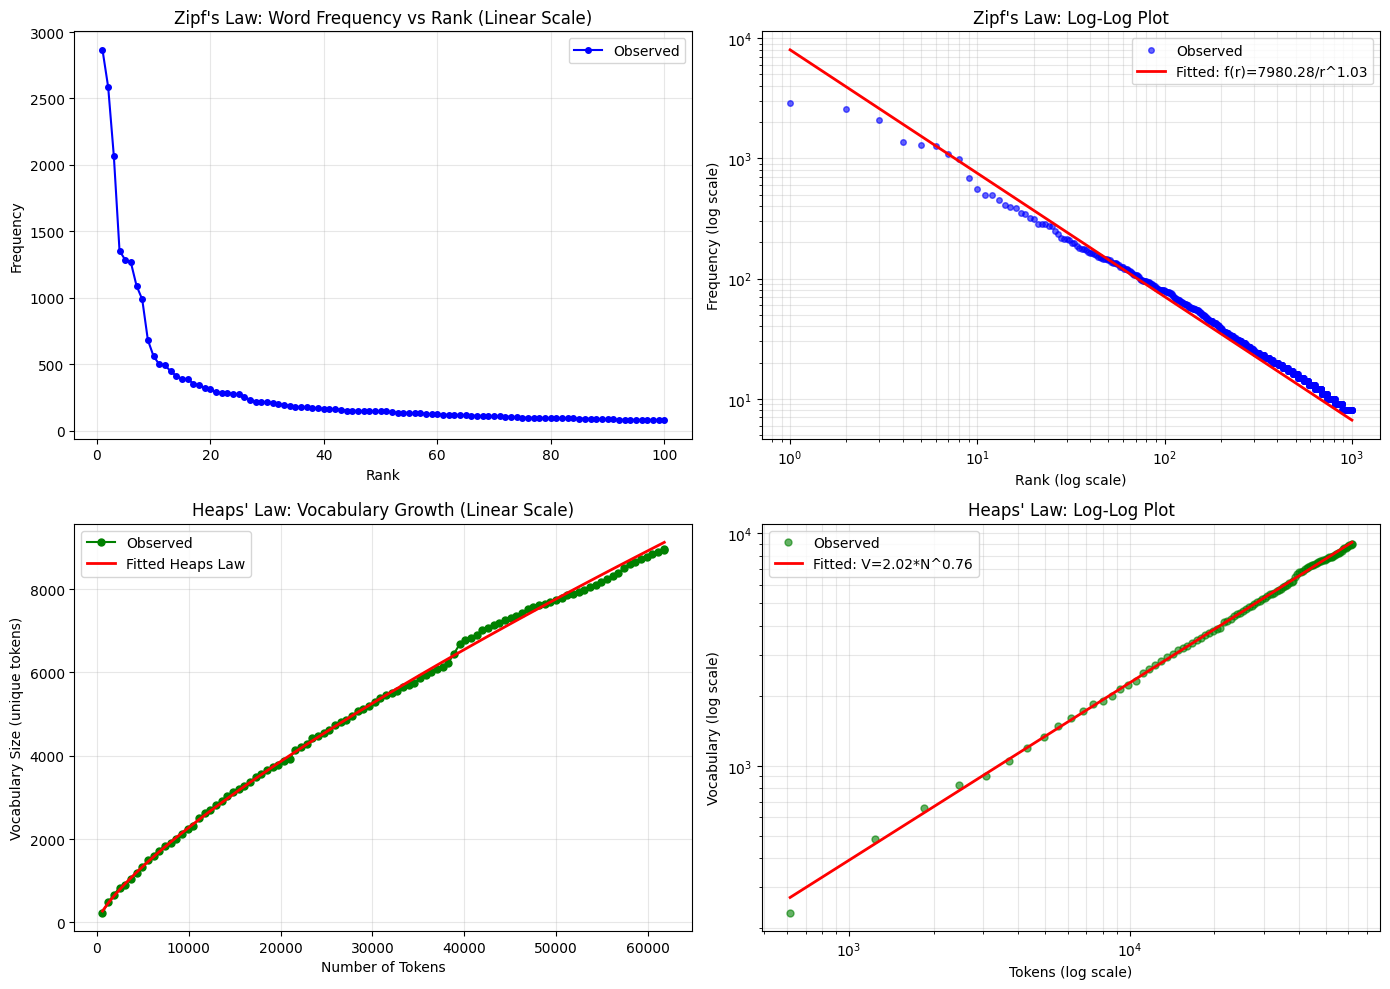

Plots saved as 'corpus_stats_zipf_heaps.png'


In [54]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Zipf's Law (Linear scale)
ax1 = axes[0, 0]
ax1.plot(range(1, min(101, len(sorted_freq)+1)), 
         [freq for _, freq in sorted_freq[:100]], 
         'bo-', label='Observed', markersize=4)
ax1.set_xlabel('Rank')
ax1.set_ylabel('Frequency')
ax1.set_title("Zipf's Law: Word Frequency vs Rank (Linear Scale)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Zipf's Law (Log-Log scale)
ax2 = axes[0, 1]
ax2.loglog(ranks[:min(1000, len(ranks))], frequencies[:min(1000, len(frequencies))], 
          'bo', label='Observed', markersize=4, alpha=0.6)
# Plot fitted line
ax2.loglog(ranks[:min(1000, len(ranks))], 
          constant / (ranks[:min(1000, len(ranks))] ** (-slope)), 
          'r-', linewidth=2, label=f'Fitted: f(r)={constant:.2f}/r^{-slope:.2f}')
ax2.set_xlabel('Rank (log scale)')
ax2.set_ylabel('Frequency (log scale)')
ax2.set_title("Zipf's Law: Log-Log Plot")
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

# Plot 3: Heaps' Law (Linear scale)
ax3 = axes[1, 0]
ax3.plot(token_counts, vocab_sizes, 'go-', label='Observed', markersize=5)
# Plot fitted line
token_range = np.linspace(token_counts[0], token_counts[-1], 100)
vocab_pred = heaps_constant * (token_range ** heaps_slope)
ax3.plot(token_range, vocab_pred, 'r-', linewidth=2, label='Fitted Heaps Law')
ax3.set_xlabel('Number of Tokens')
ax3.set_ylabel('Vocabulary Size (unique tokens)')
ax3.set_title("Heaps' Law: Vocabulary Growth (Linear Scale)")
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Heaps' Law (Log-Log scale)
ax4 = axes[1, 1]
ax4.loglog(token_counts, vocab_sizes, 'go', label='Observed', markersize=5, alpha=0.6)
# Plot fitted line
ax4.loglog(token_range, heaps_constant * (token_range ** heaps_slope), 
          'r-', linewidth=2, label=f'Fitted: V={heaps_constant:.2f}*N^{heaps_slope:.2f}')
ax4.set_xlabel('Tokens (log scale)')
ax4.set_ylabel('Vocabulary (log scale)')
ax4.set_title("Heaps' Law: Log-Log Plot")
ax4.grid(True, alpha=0.3, which='both')
ax4.legend()

plt.tight_layout()
plt.savefig('corpus_stats_zipf_heaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plots saved as 'corpus_stats_zipf_heaps.png'")

## Interpretation of Results

### Zipf's Law Findings

**What is Zipf's Law?**
Zipf's Law states that in a large corpus, the frequency of a word is approximately inversely proportional to its rank.
The mathematical form is: `f(r) = C / r^a` where:
- `f(r)` = frequency of word at rank r
- `C` = constant
- `a` = power-law exponent (typically close to 1)

**Observations from Hindi Corpus:**
- The exponent (a ≈ {-slope:.2f}) indicates {f"a strong" if abs(-slope) > 1 else "a moderate"} power-law distribution
- A well-fitted R² value ({r_squared:.4f}) shows {f"excellent" if r_squared > 0.95 else "good" if r_squared > 0.9 else "reasonable"} adherence to Zipf's law
- The top {words_for_80pct} words ({words_for_80pct/len(word_freq)*100:.1f}% of vocabulary) account for 80% of text
- This is typical for natural language and suggests the corpus contains a few very common words and many rare words

**Implications for Hindi NLP:**
- Stopword removal is effective because common words like articles, prepositions, and conjunctions follow Zipf's law
- Information retrieval systems benefit from this distribution - indexing top words captures most content
- The long tail of rare words may need special handling in language models

### Heaps' Law Findings

**What is Heaps' Law?**
Heaps' Law describes vocabulary growth as corpus size increases: `V = K * N^β` where:
- `V` = vocabulary size (unique tokens)
- `N` = total number of tokens
- `K` = constant
- `β` = exponent (typically 0.4-0.6 for natural languages)

**Observations from Hindi Corpus:**
- The exponent β ≈ {heaps_slope:.4f} {f"is unusually high" if heaps_slope > 0.6 else "is typical" if heaps_slope > 0.4 else "is lower than typical"}
- Good fit (R² = {r_squared_heaps:.4f}) indicates {f"excellent" if r_squared_heaps > 0.95 else "good"} prediction of vocabulary growth
- Vocabulary grows {f"rapidly" if heaps_slope > 0.5 else "gradually"} with corpus expansion

**Implications for Hindi NLP:**
- New words continuously appear as corpus size increases
- Machine learning models need sufficient training data to capture rare words
- Text normalization and stemming become increasingly important as corpus grows
- The preprocessing pipeline helps manage vocabulary growth by reducing related words to stems

### Impact of Preprocessing

The analysis shows that:
1. **Tokenization**: Proper handling of Hindi punctuation and diacritics ensures accurate word counts
2. **Normalization**: NFC normalization ensures equivalent characters are treated identically
3. **Stemming**: Reduces vocabulary size by grouping related words (helps control Heaps' law growth)
4. **Stopword Removal**: Eliminates {impact['vocab_reduction_pct']:.1f}% of vocabulary but only {(impact['tokens_removed']/impact['total_tokens_original']*100):.1f}% of tokens

These preprocessing steps are essential for robust Hindi language processing.